<h1 align="center">
   Large Language Diffusion Models
</h1>

In [ ]:
!pip install -q transformers datasets torch python-dotenv

In [ ]:
!pip install -q -U bitsandbytes peft accelerate transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.4 MB/s eta 0:00:00


In [ ]:
import json
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import DatasetDict, load_dataset
from dotenv import load_dotenv
from peft import LoraConfig, PeftModel, TaskType, get_peft_model, prepare_model_for_kbit_training
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, BitsAndBytesConfig

# Preprocessing Dataset

In [ ]:
load_dotenv()

### Load Dataset

In [ ]:
dataset = load_dataset("gretelai/synthetic_text_to_sql", split="train")
dataset

Dataset({
    features: ['id', 'domain', 'domain_description', 'sql_complexity', 'sql_complexity_description', 'sql_task_type', 'sql_task_type_description', 'sql_prompt', 'sql_context', 'sql', 'sql_explanation'],
    num_rows: 100000
})

In [ ]:
for key, value in dataset[0].items():
    print(f"{key}: {value}")
    print(100 * "-")

id: 5097
----------------------------------------------------------------------------------------------------
domain: forestry
----------------------------------------------------------------------------------------------------
domain_description: Comprehensive data on sustainable forest management, timber production, wildlife habitat, and carbon sequestration in forestry.
----------------------------------------------------------------------------------------------------
sql_complexity: single join
----------------------------------------------------------------------------------------------------
sql_complexity_description: only one join (specify inner, outer, cross)
----------------------------------------------------------------------------------------------------
sql_task_type: analytics and reporting
----------------------------------------------------------------------------------------------------
sql_task_type_description: generating reports, dashboards, and analytical insight

### Split Dataset

In [ ]:
remaining_dataset = dataset.train_test_split(test_size=1600, seed=42)["test"]
train_valid_split = remaining_dataset.train_test_split(test_size=600, seed=42)
test_valid_split = train_valid_split["test"].train_test_split(test_size=0.5, seed=42)

split_dataset = DatasetDict({
    "train": train_valid_split["train"],
    "validation": test_valid_split["train"],
    "test": test_valid_split["test"],
})

print(f"Train size: {len(split_dataset['train'])}")
print(f"Validation size: {len(split_dataset['validation'])}")
print(f"Test size: {len(split_dataset['test'])}")

Train size: 1000
Validation size: 300
Test size: 300


### Load Tokenizer

In [ ]:
model_id = "GSAI-ML/LLaDA-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

### Token IDs

In [ ]:
mask_token_id = 126336
pad_token_id = tokenizer.pad_token_id
eos_token_id = tokenizer.eos_token_id

print(f"Mask Token ID: {mask_token_id}")
print(f"Pad Token ID: {pad_token_id}")
print(f"EOS Token ID: {eos_token_id}")

Mask Token ID: 126336
Pad Token ID: 126081
EOS Token ID: 126081


### Token Strings

In [ ]:
mask_token = tokenizer.convert_ids_to_tokens(mask_token_id)
pad_token = tokenizer.convert_ids_to_tokens(pad_token_id)
eos_token = tokenizer.convert_ids_to_tokens(eos_token_id)

print(f"Mask Token: {mask_token}")
print(f"Pad Token: {pad_token}")
print(f"EOS Token: {eos_token}")

Mask Token: <|mdm_mask|>
Pad Token: <|endoftext|>
EOS Token: <|endoftext|>


### Train Length Stats

In [ ]:
schema_lengths = []
question_lengths = []
sql_lengths = []

for sample in split_dataset["train"]:
    schema = sample["sql_context"]
    question = sample["sql_prompt"]
    sql = sample["sql"]
    schema_lengths.append(len(tokenizer.encode(schema, add_special_tokens=False)))
    question_lengths.append(len(tokenizer.encode(question, add_special_tokens=False)))
    sql_lengths.append(len(tokenizer.encode(sql, add_special_tokens=False)))

print(f"Avg Schema Length (tokens): {np.mean(schema_lengths):.2f}")
print(f"Min Schema Length (tokens): {np.min(schema_lengths)}")
print(f"Max Schema Length (tokens): {np.max(schema_lengths)}")
print("-" * 50)
print(f"Avg Question Length (tokens): {np.mean(question_lengths):.2f}")
print(f"Min Question Length (tokens): {np.min(question_lengths)}")
print(f"Max Question Length (tokens): {np.max(question_lengths)}")
print("-" * 50)
print(f"Avg SQL Length (tokens): {np.mean(sql_lengths):.2f}")
print(f"Min SQL Length (tokens): {np.min(sql_lengths)}")
print(f"Max SQL Length (tokens): {np.max(sql_lengths)}")


Avg Schema Length (tokens): 91.64
Min Schema Length (tokens): 3
Max Schema Length (tokens): 399
--------------------------------------------------
Avg Question Length (tokens): 17.87
Min Question Length (tokens): 6
Max Question Length (tokens): 48
--------------------------------------------------
Avg SQL Length (tokens): 34.12
Min SQL Length (tokens): 5
Max SQL Length (tokens): 192


### Train Stats Summary

In [ ]:
df_lengths = pd.DataFrame({"Schema Length": schema_lengths, "Question Length": question_lengths, "SQL Length": sql_lengths})
length_stats = df_lengths.describe()
print("Statistics for Train Set:")
print(length_stats)

Statistics for Train Set:
       Schema Length  Question Length   SQL Length
count    1000.000000      1000.000000  1000.000000
mean       91.642000        17.866000    34.125000
std        54.526975         6.384576    19.535737
min         3.000000         6.000000     5.000000
25%        52.000000        13.000000    20.000000
50%        86.000000        17.000000    29.000000
75%       120.000000        21.000000    44.000000
max       399.000000        48.000000   192.000000


### Train Length Plots

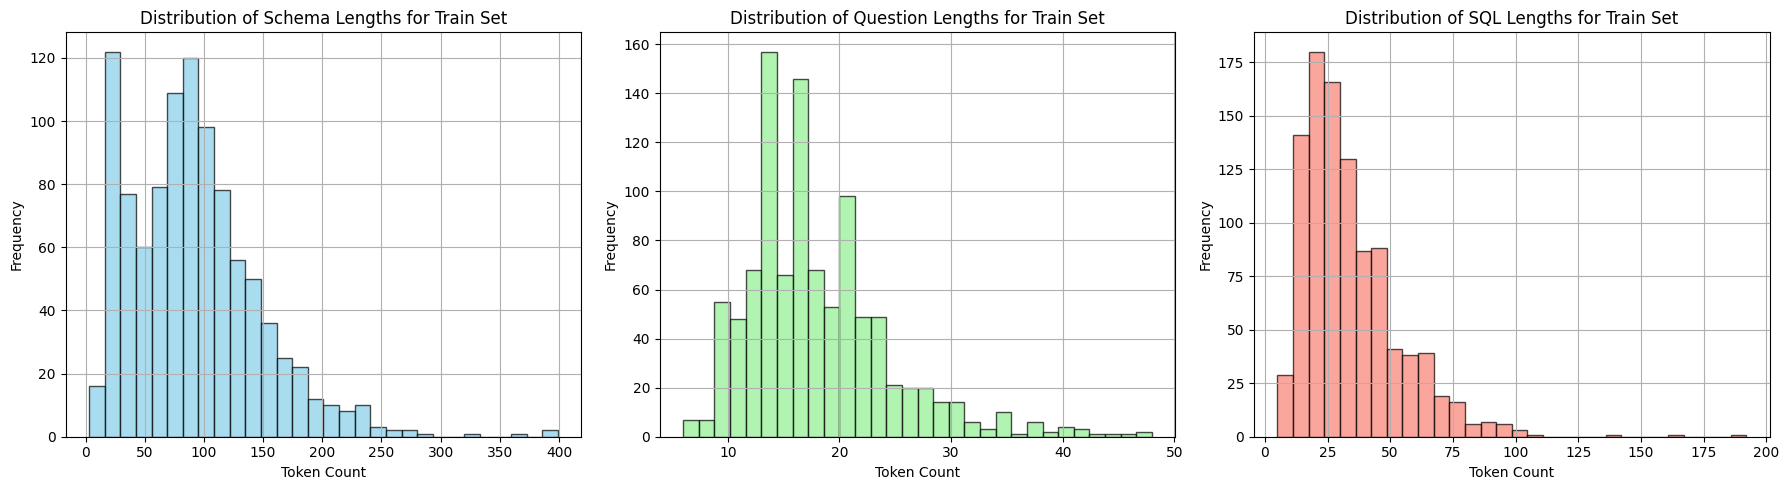

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(schema_lengths, bins=30, color="skyblue", edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of Schema Lengths for Train Set")
axes[0].set_xlabel("Token Count")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

axes[1].hist(question_lengths, bins=30, color="lightgreen", edgecolor="black", alpha=0.7)
axes[1].set_title("Distribution of Question Lengths for Train Set")
axes[1].set_xlabel("Token Count")
axes[1].set_ylabel("Frequency")
axes[1].grid(True)

axes[2].hist(sql_lengths, bins=30, color="salmon", edgecolor="black", alpha=0.7)
axes[2].set_title("Distribution of SQL Lengths for Train Set")
axes[2].set_xlabel("Token Count")
axes[2].set_ylabel("Frequency")
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Test Stats Summary

In [ ]:
schema_lengths = []
question_lengths = []
sql_lengths = []

for sample in split_dataset["test"]:
    schema = sample["sql_context"]
    question = sample["sql_prompt"]
    sql = sample["sql"]
    schema_lengths.append(len(tokenizer.encode(schema, add_special_tokens=False)))
    question_lengths.append(len(tokenizer.encode(question, add_special_tokens=False)))
    sql_lengths.append(len(tokenizer.encode(sql, add_special_tokens=False)))

df_lengths = pd.DataFrame({"Schema Length": schema_lengths, "Question Length": question_lengths, "SQL Length": sql_lengths})
length_stats = df_lengths.describe()
print("Statistics for Test Set:")
print(length_stats)

Statistics for Test Set:
       Schema Length  Question Length  SQL Length
count     300.000000       300.000000  300.000000
mean       88.123333        17.590000   31.373333
std        57.927080         6.658053   18.550680
min        13.000000         6.000000    4.000000
25%        37.500000        13.000000   18.000000
50%        84.000000        16.000000   27.000000
75%       114.000000        21.000000   38.000000
max       325.000000        49.000000  115.000000


### Test Length Plots

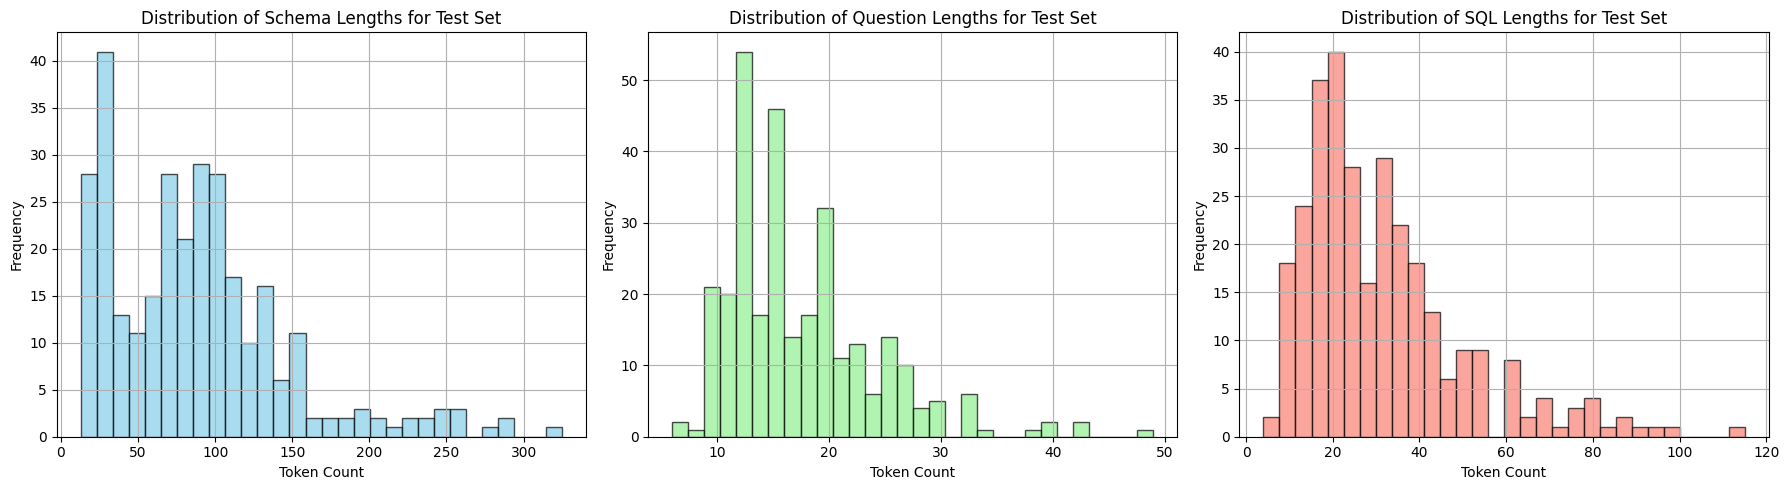

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(schema_lengths, bins=30, color="skyblue", edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of Schema Lengths for Test Set")
axes[0].set_xlabel("Token Count")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)

axes[1].hist(question_lengths, bins=30, color="lightgreen", edgecolor="black", alpha=0.7)
axes[1].set_title("Distribution of Question Lengths for Test Set")
axes[1].set_xlabel("Token Count")
axes[1].set_ylabel("Frequency")
axes[1].grid(True)

axes[2].hist(sql_lengths, bins=30, color="salmon", edgecolor="black", alpha=0.7)
axes[2].set_title("Distribution of SQL Lengths for Test Set")
axes[2].set_xlabel("Token Count")
axes[2].set_ylabel("Frequency")
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Format Examples

In [ ]:
max_seq_len = 512

def format_example(sample, return_full_text=True):
    system_prompt = (
        "You are a Text-to-SQL assistant. Output ONLY the SQL query."
        "Do not add explanations.\n"
    )

    schema = sample["sql_context"].strip()
    question = sample["sql_prompt"].strip()
    answer = sample["sql"].strip()

    buffer_tokens = 50
    question_len = len(tokenizer.encode(question, add_special_tokens=False))
    answer_len = len(tokenizer.encode(answer, add_special_tokens=False))
    schema_len = len(tokenizer.encode(schema, add_special_tokens=False))
    available_for_schema = max_seq_len - question_len - answer_len - buffer_tokens

    if schema_len > available_for_schema:
        allowed_chars = int(available_for_schema * 4)
        schema = schema[:allowed_chars] + "...(truncated)"

    user_content = f"Schema:\n{schema}\n\nQuestion:\n{question}\n"

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_content},
    ]

    if return_full_text:
        messages.append({"role": "assistant", "content": answer})

        final_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        eot_token = "<|eot_id|>"
        if eot_token in final_text:
            final_text = final_text.rsplit(eot_token, 1)[0] + eot_token
    else:
        final_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

    return final_text

### Sample Formatting

In [ ]:
sample = split_dataset["train"][0]
full_text = format_example(sample, return_full_text=True)
prompt_only = format_example(sample, return_full_text=False)

print("Full Training Sample:")
print(full_text)
print("-" * 100)
print("Prompt Only Sample:")
print(prompt_only)

Full Training Sample:
<|startoftext|><|start_header_id|>system<|end_header_id|>

You are a Text-to-SQL assistant. Output ONLY the SQL query.Do not add explanations.<|eot_id|><|start_header_id|>user<|end_header_id|>

Schema:
CREATE SCHEMA transportation; CREATE TABLE transportation.buses (id INT PRIMARY KEY, model VARCHAR(255), year INT); INSERT INTO transportation.buses (id, model, year) VALUES (1, 'Mini Bus', 2015), (2, 'City Bus', 2018), (3, 'Electric Bus', 2020);

Question:
What is the total number of buses in the 'transportation' schema?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

SELECT COUNT(*) FROM transportation.buses;<|eot_id|>
----------------------------------------------------------------------------------------------------
Prompt Only Sample:
<|startoftext|><|start_header_id|>system<|end_header_id|>

You are a Text-to-SQL assistant. Output ONLY the SQL query.Do not add explanations.<|eot_id|><|start_header_id|>user<|end_header_id|>

Schema:
CREATE SCHEMA transp

### Metrics

In [ ]:
def normalize_sql(query):
    norm_query = query.lower()
    norm_query = norm_query.replace("`", "").replace("'", "").replace('"', "")
    norm_query = norm_query.strip().rstrip(";")
    norm_query = re.sub(r"\s+", " ", norm_query).strip()
    return norm_query


def compute_raw_exact_match_metric(predictions, references):
    matches = 0
    for pred, ref in zip(predictions, references):
        if pred.strip() == ref.strip():
            matches += 1
    return matches / len(predictions)


def compute_normalized_exact_match_metric(predictions, references):
    matches = 0
    for pred, ref in zip(predictions, references):
        if normalize_sql(pred) == normalize_sql(ref):
            matches += 1
    return matches / len(predictions)

# Loading Model

In [ ]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

### Load Model

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
)

model = AutoModel.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    trust_remote_code=True,
    use_cache=False,
)

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

config.json: 0.00B [00:00, ?B/s]

configuration_llada.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/GSAI-ML/LLaDA-8B-Instruct:
- configuration_llada.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_llada.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/GSAI-ML/LLaDA-8B-Instruct:
- modeling_llada.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00005-of-00006.safetensors:   0%|          | 0.00/2.92G [00:00<?, ?B/s]

model-00006-of-00006.safetensors:   0%|          | 0.00/2.11G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

trainable params: 6,291,456 || all params: 8,021,872,640 || trainable%: 0.0784


# Training Model

### Dataset Class

In [ ]:
class TextToSQLDataset(Dataset):
    def __init__(self, input_dataset, tokenizer, max_len):
        self.data = input_dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        full_text = format_example(sample, return_full_text=True)
        prompt_text = format_example(sample, return_full_text=False)

        full_encoding = self.tokenizer(
            full_text,
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
            add_special_tokens=False,
        )
        prompt_encoding = self.tokenizer(
            prompt_text,
            truncation=False,
            add_special_tokens=False,
        )

        input_ids = full_encoding["input_ids"].squeeze(0)
        attention_mask = full_encoding["attention_mask"].squeeze(0)
        prompt_len = len(prompt_encoding["input_ids"])

        if prompt_len > self.max_len:
            prompt_len = self.max_len

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "prompt_len": prompt_len,
        }

### Training Setup

In [ ]:
num_epochs = 1
batch_size = 1
learning_rate = 2e-4
gradient_accumulation = 8

device = "cuda" if torch.cuda.is_available() else "cpu"

train_dataset = TextToSQLDataset(split_dataset["train"], tokenizer, max_seq_len)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

### Forward Process

In [ ]:
def forward_process(input_ids, prompt_lengths, mask_token_id, device):
    min_p = 0.3
    batch_size, seq_len = input_ids.shape
    p_mask = torch.rand(batch_size, device=device) * (1 - min_p) + min_p

    mask_prob = p_mask.unsqueeze(-1).expand(batch_size, seq_len)
    masked_indices = torch.bernoulli(mask_prob).bool()
    padding_mask = input_ids == tokenizer.pad_token_id

    for i in range(batch_size):
        p_len = prompt_lengths[i]
        masked_indices[i, :p_len] = False
        masked_indices[i] = masked_indices[i] & (~padding_mask[i])

        if masked_indices[i].sum() == 0:
            valid_indices = torch.arange(seq_len, device=device)
            valid_mask = (valid_indices >= p_len) & (~padding_mask[i])
            valid_candidates = valid_indices[valid_mask]

            if len(valid_candidates) > 0:
                num_to_force = 3
                indices_to_mask = valid_candidates[torch.randperm(len(valid_candidates))[:num_to_force]]
                masked_indices[i, indices_to_mask] = True
                p_mask[i] = num_to_force / len(valid_candidates)

    noisy_input_ids = input_ids.clone()
    noisy_input_ids[masked_indices] = mask_token_id

    return noisy_input_ids, masked_indices, p_mask

### Mount Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


### Save Paths

In [ ]:
save_path = "/content/drive/MyDrive/LLaDA_TextToSQL_Project_2/llada_sql_adapter"
history_path = "/content/drive/MyDrive/LLaDA_TextToSQL_Project_2/loss_history.json"
results_file = "/content/drive/MyDrive/LLaDA_TextToSQL_Project_2/test_results_backup.json"
os.makedirs(save_path, exist_ok=True)

### Train Model

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=len(train_loader) * num_epochs,
)
criterion = nn.CrossEntropyLoss(reduction="none")

loss_history = []
total_steps = len(train_loader) * num_epochs
progress_bar = tqdm(total=total_steps, desc="Training", unit="step")

model.train()
for epoch in range(num_epochs):
    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        prompt_lengths = batch["prompt_len"]

        noisy_input_ids, masked_indices, p_mask = forward_process(
            input_ids,
            prompt_lengths,
            mask_token_id,
            device,
        )
        loss_mask = masked_indices & (attention_mask.bool())

        outputs = model(input_ids=noisy_input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        flat_logits = logits.view(-1, logits.size(-1))
        flat_targets = input_ids.view(-1)
        flat_loss_mask = loss_mask.view(-1)

        raw_loss = criterion(flat_logits, flat_targets)

        p_mask_expanded = p_mask.unsqueeze(-1).expand_as(input_ids).reshape(-1)
        weights = 1 / (p_mask_expanded + 1e-4)

        masked_weighted_loss = raw_loss * weights * flat_loss_mask.float()
        loss = masked_weighted_loss.sum() / (input_ids.shape[0] * input_ids.shape[1])
        loss = loss / gradient_accumulation
        loss.backward()

        if (step + 1) % gradient_accumulation == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            actual_loss = loss.item() * gradient_accumulation
            progress_bar.set_postfix(
                loss=f"{actual_loss:.4f}",
                lr=f"{scheduler.get_last_lr()[0]:.6f}",
            )
            loss_history.append({
                "epoch": epoch + 1,
                "step": step,
                "loss": actual_loss,
                "lr": scheduler.get_last_lr()[0],
            })
            if ((step + 1) // gradient_accumulation) % 10 == 0:
                print(f"Epoch {epoch + 1} | Step {step} | Loss: {actual_loss:.4f}")

        progress_bar.update(1)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
with open(history_path, "w") as f:
    json.dump(loss_history, f, indent=4)

Training:   0%|          | 0/1000 [00:00<?, ?step/s]

Epoch 1 | Step 79 | Loss: 0.0001
Epoch 1 | Step 159 | Loss: 0.0038
Epoch 1 | Step 239 | Loss: 0.0000
Epoch 1 | Step 319 | Loss: 0.0006
Epoch 1 | Step 399 | Loss: 0.0035
Epoch 1 | Step 479 | Loss: 0.0000
Epoch 1 | Step 559 | Loss: 0.1502
Epoch 1 | Step 639 | Loss: 0.0001
Epoch 1 | Step 719 | Loss: 0.0003
Epoch 1 | Step 799 | Loss: 0.0311
Epoch 1 | Step 879 | Loss: 0.0098
Epoch 1 | Step 959 | Loss: 0.1074


### Plot Loss

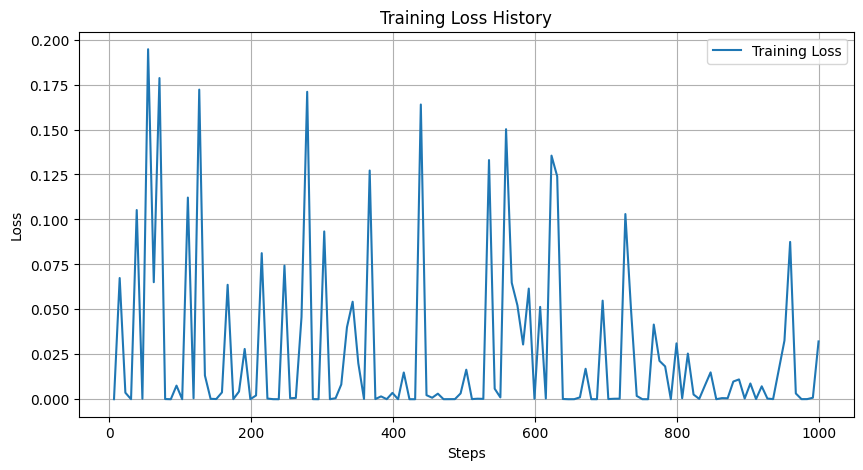

In [ ]:
steps = [entry["step"] for entry in loss_history]
losses = [entry["loss"] for entry in loss_history]

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, label="Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss History")
plt.grid(True)
plt.legend()
plt.show()

### Plot Learning Rate

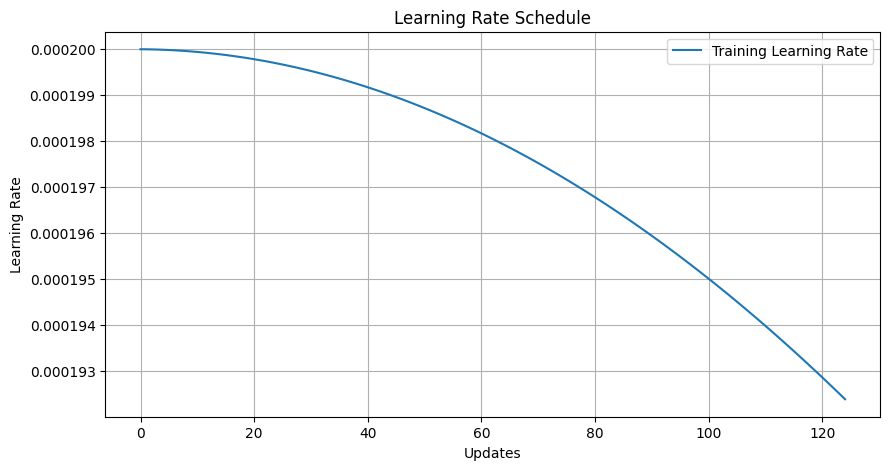

In [ ]:
lrs = [entry["lr"] for entry in loss_history]

plt.figure(figsize=(10, 5))
plt.plot(lrs, label="Training Learning Rate")
plt.xlabel("Updates")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True)
plt.legend()
plt.show()

### Plot Loss And LR

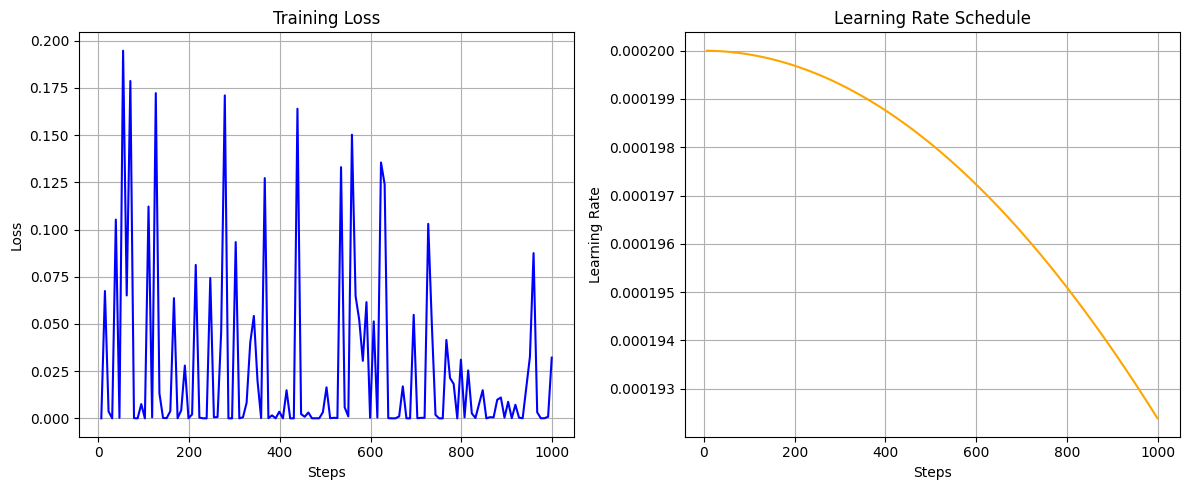

In [ ]:
losses = [entry["loss"] for entry in loss_history]
steps = [entry["step"] for entry in loss_history]
lrs = [entry["lr"] for entry in loss_history]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(steps, losses, label="Training Loss", color="blue")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(steps, lrs, label="Learning Rate", color="orange")
plt.xlabel("Steps")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluation

### Generation Utilities

In [ ]:
@torch.no_grad()
def block_diffusion_generate(
    model,
    tokenizer,
    prompt_text,
    steps=10,
    gen_length=64,
    block_length=32,
    device="cuda",
):
    model.eval()

    prompt_inputs = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False).to(device)
    prompt_ids = prompt_inputs["input_ids"]
    mask_tokens = torch.full((1, gen_length), mask_token_id, dtype=torch.long, device=device)
    input_ids = torch.cat([prompt_ids, mask_tokens], dim=1)
    num_blocks = gen_length // block_length
    prompt_len = prompt_ids.shape[1]

    for block_idx in range(num_blocks):
        start_idx = prompt_len + (block_idx * block_length)
        end_idx = start_idx + block_length
        tokens_per_step = block_length // steps

        for step in range(steps):
            outputs = model(input_ids)
            logits = outputs.logits
            block_logits = logits[:, start_idx:end_idx, :]
            probs = F.softmax(block_logits, dim=-1)
            confidence_scores, candidate_ids = torch.max(probs, dim=-1)
            current_block_ids = input_ids[:, start_idx:end_idx]
            is_masked = current_block_ids == mask_token_id

            if not is_masked.any():
                break

            masked_confidence = confidence_scores.clone()
            masked_confidence[~is_masked] = -1.0
            num_to_commit = tokens_per_step

            if step == steps - 1:
                num_to_commit = is_masked.sum().item()

            if num_to_commit > 0:
                _, topk_indices = torch.topk(masked_confidence.view(-1), k=num_to_commit)
                for rel_idx in topk_indices:
                    global_idx = start_idx + rel_idx.item()
                    selected_token = candidate_ids[0, rel_idx].item()
                    input_ids[0, global_idx] = selected_token

    generated_text = tokenizer.decode(input_ids[0, prompt_len:], skip_special_tokens=True)
    return generated_text


def post_process_sql(text):
    text = text.replace("\n", " ").strip()
    match = re.search(r"\b(SELECT|WITH|UPDATE|DELETE|INSERT)\b", text, re.IGNORECASE)

    if match:
        text = text[match.start():]

    if ";" in text:
        text = text.split(";")[0] + ";"

    return text.strip()

### Sample Generation 1

In [ ]:
sample_example = split_dataset["test"][0]
sample_ground_truth = sample_example["sql"]
sample_prompt = format_example(sample_example, return_full_text=False)
gen_sql = block_diffusion_generate(
    model,
    tokenizer,
    sample_prompt,
    steps=16,
    gen_length=128,
    block_length=32,
)
clean_sql = post_process_sql(gen_sql)

print(f"Ground Truth:  {sample_ground_truth}")
print(f"Generated SQL: {gen_sql}")
print(f"Cleaned SQL:   {clean_sql}")

Ground Truth:  SELECT gender, COUNT(author_id) as num_authors FROM ArticleAuthors aa JOIN Authors a ON aa.author_id = a.id GROUP BY gender;
Generated SQL: SELECT gender, COUNT(*) FROM Authors a JOIN ArticleAuthors aa ON a.id = aa.author_id GROUP BY gender;
Cleaned SQL:   SELECT gender, COUNT(*) FROM Authors a JOIN ArticleAuthors aa ON a.id = aa.author_id GROUP BY gender;


### Sample Generation 2

In [ ]:
sample_example = split_dataset["test"][0]
sample_ground_truth = sample_example["sql"]
sample_prompt = format_example(sample_example, return_full_text=False)
gen_sql = block_diffusion_generate(
    model,
    tokenizer,
    sample_prompt,
    steps=16,
    gen_length=32,
    block_length=16,
)
clean_sql = post_process_sql(gen_sql)

print(f"Ground Truth:  {sample_ground_truth}")
print(f"Generated SQL: {gen_sql}")
print(f"Cleaned SQL:   {clean_sql}")

Ground Truth:  SELECT gender, COUNT(author_id) as num_authors FROM ArticleAuthors aa JOIN Authors a ON aa.author_id = a.id GROUP BY gender;
Generated SQL: SELECT COUNT(gender) FROM Authors WHERE gender = 'Female' UNION SELECT COUNT(gender) FROM Authors WHERE gender = 'Male' UNION;
Cleaned SQL:   SELECT COUNT(gender) FROM Authors WHERE gender = 'Female' UNION SELECT COUNT(gender) FROM Authors WHERE gender = 'Male' UNION;


### Sample Generation 3

In [ ]:
sample_example = split_dataset["test"][0]
sample_ground_truth = sample_example["sql"]
sample_prompt = format_example(sample_example, return_full_text=False)
gen_sql = block_diffusion_generate(
    model,
    tokenizer,
    sample_prompt,
    steps=12,
    gen_length=40,
    block_length=20,
)
clean_sql = post_process_sql(gen_sql)

print(f"Ground Truth:  {sample_ground_truth}")
print(f"Generated SQL: {gen_sql}")
print(f"Cleaned SQL:   {clean_sql}")

Ground Truth:  SELECT gender, COUNT(author_id) as num_authors FROM ArticleAuthors aa JOIN Authors a ON aa.author_id = a.id GROUP BY gender;
Generated SQL: SELECT COUNT(gender) as female_count, COUNT(gender) as male_count FROM Authors GROUP BY gender HAVING COUNT(gender) > 0 ORDER BY female(gender) DESC;
Cleaned SQL:   SELECT COUNT(gender) as female_count, COUNT(gender) as male_count FROM Authors GROUP BY gender HAVING COUNT(gender) > 0 ORDER BY female(gender) DESC;


### Sample Generation 4

In [ ]:
sample_example = split_dataset["test"][0]
sample_ground_truth = sample_example["sql"]
sample_prompt = format_example(sample_example, return_full_text=False)
gen_sql = block_diffusion_generate(
    model,
    tokenizer,
    sample_prompt,
    steps=16,
    gen_length=96,
    block_length=32,
)
clean_sql = post_process_sql(gen_sql)

print(f"Ground Truth:  {sample_ground_truth}")
print(f"Generated SQL: {gen_sql}")
print(f"Cleaned SQL:   {clean_sql}")

Ground Truth:  SELECT gender, COUNT(author_id) as num_authors FROM ArticleAuthors aa JOIN Authors a ON aa.author_id = a.id GROUP BY gender;
Generated SQL: SELECT COUNT(DISTINCT) as FemaleAuthors, COUNT(DISTINCT) as maleAuthors FROM ArticleAuthors WHERE gender = 'Female' OR gender = 'Male';
Cleaned SQL:   SELECT COUNT(DISTINCT) as FemaleAuthors, COUNT(DISTINCT) as maleAuthors FROM ArticleAuthors WHERE gender = 'Female' OR gender = 'Male';


### Sample Generation 5

In [ ]:
sample_example = split_dataset["test"][0]
sample_ground_truth = sample_example["sql"]
sample_prompt = format_example(sample_example, return_full_text=False)
gen_sql = block_diffusion_generate(
    model,
    tokenizer,
    sample_prompt,
    steps=16,
    gen_length=64,
    block_length=32,
)
clean_sql = post_process_sql(gen_sql)

print(f"Ground Truth:  {sample_ground_truth}")
print(f"Generated SQL: {gen_sql}")
print(f"Cleaned SQL:   {clean_sql}")

Ground Truth:  SELECT gender, COUNT(author_id) as num_authors FROM ArticleAuthors aa JOIN Authors a ON aa.author_id = a.id GROUP BY gender;
Generated SQL: SELECT gender, COUNT(*) FROM Authors a JOIN ArticleAuthors aa ON a.id = aa.author_id GROUP BY gender;
Cleaned SQL:   SELECT gender, COUNT(*) FROM Authors a JOIN ArticleAuthors aa ON a.id = aa.author_id GROUP BY gender;


### Evaluate Model

In [ ]:
save_every = 2
gen_length = 64
block_length = 32
steps_per_block = 16
test_samples = 200

results = []
test_dataset = split_dataset["test"].select(range(test_samples))

for i, sample in tqdm(enumerate(test_dataset), total=test_samples):
    prompt = format_example(sample, return_full_text=False)
    ground_truth = sample["sql"]

    raw_output = block_diffusion_generate(
        model,
        tokenizer,
        prompt,
        steps=steps_per_block,
        gen_length=gen_length,
        block_length=block_length,
    )
    clean_sql = post_process_sql(raw_output)
    score = compute_normalized_exact_match_metric([clean_sql], [ground_truth])

    results.append({
        "number": i,
        "prompt": sample["sql_prompt"],
        "ground_truth": ground_truth,
        "raw_output": raw_output,
        "clean_sql": clean_sql,
        "score": score,
    })

    if (i + 1) % save_every == 0 or (i + 1) == test_samples:
        with open(results_file, "w") as f:
            json.dump(results, f, indent=4)

 37%|###7      | 74/200 [00:00<?, ?it/s]

### Load Adapter

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
)

base_model = AutoModel.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    trust_remote_code=True,
    use_cache=False,
)

model = PeftModel.from_pretrained(base_model, save_path)

config.json: 0.00B [00:00, ?B/s]

configuration_llada.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/GSAI-ML/LLaDA-8B-Instruct:
- configuration_llada.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_llada.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/GSAI-ML/LLaDA-8B-Instruct:
- modeling_llada.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00006-of-00006.safetensors:   0%|          | 0.00/2.11G [00:00<?, ?B/s]

model-00002-of-00006.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

model-00001-of-00006.safetensors:   0%|          | 0.00/2.11G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/128 [00:00<?, ?B/s]

### Adapter Sample Generation

In [ ]:
sample_example = split_dataset["test"][0]
sample_ground_truth = sample_example["sql"]
sample_prompt = format_example(sample_example, return_full_text=False)
gen_sql = block_diffusion_generate(
    model,
    tokenizer,
    sample_prompt,
    steps=16,
    gen_length=64,
    block_length=32,
)
clean_sql = post_process_sql(gen_sql)

print(f"Ground Truth:  {sample_ground_truth}")
print(f"Generated SQL: {gen_sql}")
print(f"Cleaned SQL:   {clean_sql}")

Ground Truth:  SELECT gender, COUNT(author_id) as num_authors FROM ArticleAuthors aa JOIN Authors a ON aa.author_id = a.id GROUP BY gender;
Generated SQL: SELECT gender, COUNT(*) FROM Authors a JOIN ArticleAuthors aa ON a.id = aa.author_id GROUP BY gender;
Cleaned SQL:   SELECT gender, COUNT(*) FROM Authors a JOIN ArticleAuthors aa ON a.id = aa.author_id GROUP BY gender;


### Resume Evaluation

In [ ]:
save_every = 1
gen_length = 64
block_length = 32
steps_per_block = 16
test_samples = 200

results = []
start_index = 0
test_dataset = split_dataset["test"].select(range(test_samples))

if os.path.exists(results_file):
    print(f"Found backup file at {results_file}")
    with open(results_file, "r") as f:
        results = json.load(f)
    start_index = len(results)

with torch.no_grad():
    for i in tqdm(range(start_index, test_samples), total=test_samples, initial=start_index):
        sample = test_dataset[i]
        prompt = format_example(sample, return_full_text=False)
        ground_truth = sample["sql"]

        raw_output = block_diffusion_generate(
            model,
            tokenizer,
            prompt,
            steps=steps_per_block,
            gen_length=gen_length,
            block_length=block_length,
        )
        clean_sql = post_process_sql(raw_output)
        score = compute_normalized_exact_match_metric([clean_sql], [ground_truth])

        results.append({
            "number": i,
            "prompt": sample["sql_prompt"],
            "ground_truth": ground_truth,
            "raw_output": raw_output,
            "clean_sql": clean_sql,
            "score": score,
        })

        if (i + 1) % save_every == 0 or (i + 1) == test_samples:
            with open(results_file, "w") as f:
                json.dump(results, f, indent=4)

Found backup file at /content/drive/MyDrive/LLaDA_TextToSQL_Project_2/test_results_backup.json


 74%|#######4  | 148/200 [00:00<?, ?it/s]

### Compute Accuracy

In [ ]:
accuracies = [r["score"] for r in results]
avg_accuracy = sum(accuracies) / len(accuracies)

print(f"Final Normalized Exact Match Score: {avg_accuracy:.2%}")

Final Normalized Exact Match Score: 27.00%


### Show Examples 20

In [ ]:
for i in range(20):
    res = results[i]
    status = "Correct" if res["score"] == 1 else "Not Exactly Matches"
    example_header = f" Example {i + 1} "
    print(f"{example_header:-^100}")
    print(f"Question: {res['prompt']}")
    print(f"Ground Truth: {res['ground_truth']}")
    print(f"Prediction: {res['clean_sql']}")
    print(f"Status: {status}")
    print()

-------------------------------------------- Example 1 ---------------------------------------------
Question: How many female and male authors have contributed to the articles?
Ground Truth: SELECT gender, COUNT(author_id) as num_authors FROM ArticleAuthors aa JOIN Authors a ON aa.author_id = a.id GROUP BY gender;
Prediction: SELECT gender, COUNT(*) FROM Authors a JOIN ArticleAuthors aa ON a.id = aa.author_id GROUP BY gender;
Status: Not Exactly Matches

-------------------------------------------- Example 2 ---------------------------------------------
Question: What is the average depth of ocean floor mapping project sites in the Pacific region?
Ground Truth: SELECT avg(avg_depth) FROM ocean_floor_map WHERE region = 'Pacific';
Prediction: SELECT AVG(avg_depth) FROM ocean_floor_map WHERE region = 'Pacific';
Status: Correct

-------------------------------------------- Example 3 ---------------------------------------------
Question: Show all records from the visual impairment view
Gr

### Show Examples 200

In [ ]:
for i in range(200):
    res = results[i]
    status = "Correct" if res["score"] == 1 else "Not Exactly Matches"
    example_header = f" Example {i + 1} "
    print(f"{example_header:-^100}")
    print(f"Question: {res['prompt']}")
    print(f"Ground Truth: {res['ground_truth']}")
    print(f"Prediction: {res['clean_sql']}")
    print(f"Status: {status}")
    print()

-------------------------------------------- Example 1 ---------------------------------------------
Question: How many female and male authors have contributed to the articles?
Ground Truth: SELECT gender, COUNT(author_id) as num_authors FROM ArticleAuthors aa JOIN Authors a ON aa.author_id = a.id GROUP BY gender;
Prediction: SELECT gender, COUNT(*) FROM Authors a JOIN ArticleAuthors aa ON a.id = aa.author_id GROUP BY gender;
Status: Not Exactly Matches

-------------------------------------------- Example 2 ---------------------------------------------
Question: What is the average depth of ocean floor mapping project sites in the Pacific region?
Ground Truth: SELECT avg(avg_depth) FROM ocean_floor_map WHERE region = 'Pacific';
Prediction: SELECT AVG(avg_depth) FROM ocean_floor_map WHERE region = 'Pacific';
Status: Correct

-------------------------------------------- Example 3 ---------------------------------------------
Question: Show all records from the visual impairment view
Gr